In [6]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plts

drinking_df = pd.read_csv("smoking_driking_dataset_Ver01.csv")
drinking_df

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,1.0,N
991342,Male,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,1.0,N
991343,Female,40,155,50,68.0,1.0,0.7,1.0,1.0,110.0,...,77.0,157.0,14.3,1.0,0.8,30.0,27.0,17.0,3.0,Y
991344,Male,25,175,60,72.0,1.5,1.0,1.0,1.0,119.0,...,73.0,53.0,14.5,1.0,0.8,21.0,14.0,17.0,1.0,N


In [7]:
num_duplicates = drinking_df.duplicated().sum()
num_total = drinking_df.shape[0]
num_unique = num_total - num_duplicates
print(f"Prosent beholdt: {(num_unique / num_total) * 100:.10f}%")
drinking_df_unique = drinking_df.drop_duplicates()

Prosent beholdt: 99.9973773032%


In [8]:
import numpy as np
import pandas as pd

df = drinking_df_unique.copy()

cat_cols = ["sex", "SMK_stat_type_cd", "DRK_YN", "urine_protein", "hear_left", "hear_right"]
no_log = ["SMK_stat_type_cd", "urine_protein", "hemoglobin", "hear_right", "hear_left", "weight", "height", "age"]

df_log = df.copy()

def transform_with_optional_log(df, col, allow_log=True):

    global df_log

    if col not in df.columns:
        return

    data = df[col].dropna()
    if data.empty:
        return

    if col in cat_cols:
        return

    if allow_log and (data > 0).all():
        log_series = np.log10(data)     
        df_log.loc[log_series.index, col] = log_series

for col in df.columns:
    allow_log = (col not in no_log and col not in cat_cols)
    transform_with_optional_log(df, col, allow_log=allow_log)

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

df = df_log.copy()

columns_to_check = [
    "age", "height", "weight", "waistline",
    "sight_left", "sight_right",
    "SBP", "DBP", "BLDS",
    "tot_chole", "HDL_chole", "LDL_chole", "triglyceride",
    "hemoglobin", "serum_creatinine", "SGOT_AST", "SGOT_ALT", "gamma_GTP",
]

# Beregn z-scores per kolonne (NaN ignoreres i sammenligningen under)
z_scores = df[columns_to_check].apply(zscore)

# Behold rader der alle valgte kolonner har |z| <= 3
mask = (np.abs(z_scores) <= 3).all(axis=1)
df_clean = df[mask].copy()

print(f"Rows before: {len(df)}, after outlier removal: {len(df_clean)}")

# df_clean er nå datasettet uten outliers etter z-score-kriteriets

Rows before: 991320, after outlier removal: 877018


In [15]:
import pandas as pd
import numpy as np

# ===============================
# 0) Start fra df_clean (allerede outlier-filtert)
# ===============================
df = df_clean.copy()

# Normaliser kolonnenavn
df.columns = [c.strip().lower() for c in df.columns]

# Konverter til numerisk der mulig
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="ignore")

# Trygg deling (funksjon som takler både Series og skalar)
def safe_div(num, den):
    num = pd.to_numeric(num, errors="coerce")
    if np.isscalar(den):
        den_val = float(den)
        if den_val == 0:
            return pd.Series(np.nan, index=getattr(num, "index", None)) if hasattr(num, "index") else np.nan
        out = np.divide(num, den_val)
        return pd.Series(out, index=num.index) if hasattr(num, "index") else out
    else:
        den = pd.to_numeric(den, errors="coerce")
        num_arr = num.to_numpy() if hasattr(num, "to_numpy") else num
        den_arr = den.to_numpy() if hasattr(den, "to_numpy") else den
        where_mask = (~pd.isna(num_arr)) & (~pd.isna(den_arr)) & (den_arr != 0)
        out = np.full_like(num_arr, np.nan, dtype="float64")
        np.divide(num_arr, den_arr, out=out, where=where_mask)
        return pd.Series(out, index=getattr(num, "index", None)) if hasattr(num, "index") else out

# ===============================
# 1) Feature engineering (uten obese/bmi_cat, og UTEN sight/hear-aggregater)
# ===============================

# BMI
if {"height", "weight"}.issubset(df.columns):
    valid_h = pd.to_numeric(df["height"], errors="coerce") > 0
    df.loc[valid_h, "bmi"] = df.loc[valid_h, "weight"] / ((df.loc[valid_h, "height"]/100.0) ** 2)

# Hemoglobin-kategori (tertiler)
if "hemoglobin" in df.columns:
    try:
        df["hemoglobin_cat"] = pd.qcut(pd.to_numeric(df["hemoglobin"], errors="coerce"), 3,
                                       labels=["low", "middle", "high"])
    except ValueError:
        df["hemoglobin_cat"] = pd.cut(pd.to_numeric(df["hemoglobin"], errors="coerce"), 3,
                                      labels=["low", "middle", "high"])

# Gamma-GTP kategori (kvintiler)
if "gamma_gtp" in df.columns:
    gamma_series = pd.to_numeric(df["gamma_gtp"], errors="coerce")
    try:
        df["gamma_cat"] = pd.qcut(gamma_series, 5, labels=["very_low","low","middle","high","very_high"])
    except ValueError:
        df["gamma_cat"] = pd.cut(gamma_series, 5, labels=["very_low","low","middle","high","very_high"])

# Totalkolesterol som enkel sum (beholdes)
if {"ldl_chole","hdl_chole","triglyceride"}.issubset(df.columns):
    df["total_cholesterol_sum"] = (
        pd.to_numeric(df["ldl_chole"], errors="coerce")
      + pd.to_numeric(df["hdl_chole"], errors="coerce")
      + pd.to_numeric(df["triglyceride"], errors="coerce")
    )

# Lever-ratios + index (mellomregninger droppes senere)
if {"sgot_ast","sgot_alt"}.issubset(df.columns):
    df["sgot_alt"] = safe_div(df["sgot_ast"], df["sgot_alt"])
if {"gamma_gtp","sgot_ast"}.issubset(df.columns):
    df["gamma_gtp_ast"] = safe_div(df["gamma_gtp"], df["sgot_ast"])
if {"sgot_alt","gamma_gtp_ast"}.issubset(df.columns):
    df["liver_function_index"] = df[["sgot_alt","gamma_gtp_ast"]].apply(pd.to_numeric, errors="coerce").mean(axis=1)

# Nyre-index
if {"serum_creatinine","urine_protein"}.issubset(df.columns):
    df["kidney_function_index"] = safe_div(df["serum_creatinine"], 1.2) + safe_div(df["urine_protein"], 150)

# Metabolic panel (sum av markører)
met_cols = [c for c in ["hemoglobin","serum_creatinine","sgot_ast","sgot_alt","gamma_gtp"] if c in df.columns]
if met_cols:
    df["metabolic_panel"] = df[met_cols].apply(pd.to_numeric, errors="coerce").sum(axis=1)

# ===============================
# 2) Dropp råkolonner + eksplisitt uønskede
#    (MEN behold sight/hear + smk_stat_type_cd + drk_yn)
# ===============================
to_drop = [
    "gamma_cat",
    "hemoglobin_cat",
    "waistline",
    # rådata brukt i transformasjoner
    "height","weight","age",
    "tot_chole","hdl_chole","ldl_chole","triglyceride",
    "sgot_ast","sgot_alt","gamma_gtp","serum_creatinine","urine_protein",
    "hemoglobin",
    # blodtrykk rå
    "sbp","dbp",
    # alder-kategori
    "age_cat",
    # eksplisitt uønskede / redundante
    "tc_hdl","tg_hdl","gamma_gtp_ast","wht_r",
    "bpi","cv_risk","total_cholesterol_friedewald","cardiovascular_health_index",
    # tidligere ønsket fjernet
    "obese","bmi_cat",
    # IKKE dropp disse: sight_left, sight_right, hear_left, hear_right, smk_stat_type_cd, drk_yn, smk_cat
    "sight_left","sight_right","hear_left","hear_right"
]
df = df.drop(columns=[c for c in to_drop if c in df.columns], errors="ignore")

# ===============================
# 3) Kode kategorier som skal beholdes til tall
# ===============================
# sex (hvis tekst)
if "sex" in df.columns and df["sex"].dtype == "object":
    df["sex"] = df["sex"].str.lower().map({"male":0, "m":0, "female":1, "f":1})

# hemoglobin_cat (ordinal 0..2)
if "hemoglobin_cat" in df.columns and df["hemoglobin_cat"].dtype == "object":
    df["hemoglobin_cat"] = df["hemoglobin_cat"].map({"low":0, "middle":1, "high":2})

# gamma_cat (ordinal 0..4)
if "gamma_cat" in df.columns and df["gamma_cat"].dtype == "object":
    df["gamma_cat"] = df["gamma_cat"].map({"very_low":0, "low":1, "middle":2, "high":3, "very_high":4})

# smk_stat_type_cd: behold som tall (1=never,2=quit,3=smoker) -> skaleres senere
# smk_cat: hvis finnes som tekst, gjør den binær (0/1)
if "smk_cat" in df.columns and df["smk_cat"].dtype == "object":
    df["smk_cat"] = df["smk_cat"].map({"normal":0, "high":1})

# drk_yn: mappe til 0/1 hvis tekst
if "drk_yn" in df.columns and df["drk_yn"].dtype == "object":
    df["drk_yn"] = df["drk_yn"].str.upper().map({"N":0, "Y":1})

# ===============================
# 4) Skaler ALT til [0,1] (inkl. sight/hear + smk_stat_type_cd + drk_yn)
# ===============================
def minmax_scale_01(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce")
    xmin = x.min(skipna=True); xmax = x.max(skipna=True)
    if pd.isna(xmin) or pd.isna(xmax) or xmax == xmin:
        return x.apply(lambda v: np.nan if pd.isna(v) else 0.0)
    return (x - xmin) / (xmax - xmin)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = df[num_cols].apply(minmax_scale_01, axis=0)

# ===============================
# 5) Lagre
# ===============================
out_path = "drinking_df_ready_for_clustering_v3.csv"
df.to_csv(out_path, index=False)
print(f"✅ Saved dataset with sight/hear + smk_stat_type_cd + drk_yn kept and scaled to [0,1] -> {out_path}")


C:\Users\hanev\AppData\Local\Temp\ipykernel_15384\1904835389.py:14: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


✅ Saved dataset with sight/hear + smk_stat_type_cd + drk_yn kept and scaled to [0,1] -> drinking_df_ready_for_clustering_v3.csv


In [ ]:
import pandas as pd
import numpy as np

# ===============================
# 0) Start fra df_clean (allerede outlier-filtert)
# ===============================
df = df_clean.copy()

# Normaliser kolonnenavn
df.columns = [c.strip().lower() for c in df.columns]

# Konverter til numerisk der mulig
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="ignore")

# Trygg deling (funksjon som takler både Series og skalar)
def safe_div(num, den):
    num = pd.to_numeric(num, errors="coerce")
    if np.isscalar(den):
        den_val = float(den)
        if den_val == 0:
            return pd.Series(np.nan, index=getattr(num, "index", None)) if hasattr(num, "index") else np.nan
        out = np.divide(num, den_val)
        return pd.Series(out, index=num.index) if hasattr(num, "index") else out
    else:
        den = pd.to_numeric(den, errors="coerce")
        num_arr = num.to_numpy() if hasattr(num, "to_numpy") else num
        den_arr = den.to_numpy() if hasattr(den, "to_numpy") else den
        where_mask = (~pd.isna(num_arr)) & (~pd.isna(den_arr)) & (den_arr != 0)
        out = np.full_like(num_arr, np.nan, dtype="float64")
        np.divide(num_arr, den_arr, out=out, where=where_mask)
        return pd.Series(out, index=getattr(num, "index", None)) if hasattr(num, "index") else out

# ===============================
# 1) Feature engineering (uten obese/bmi_cat, og UTEN sight/hear-aggregater)
# ===============================

# BMI
if {"height", "weight"}.issubset(df.columns):
    valid_h = pd.to_numeric(df["height"], errors="coerce") > 0
    df.loc[valid_h, "bmi"] = df.loc[valid_h, "weight"] / ((df.loc[valid_h, "height"]/100.0) ** 2)

# Hemoglobin-kategori (tertiler)
if "hemoglobin" in df.columns:
    try:
        df["hemoglobin_cat"] = pd.qcut(pd.to_numeric(df["hemoglobin"], errors="coerce"), 3,
                                       labels=["low", "middle", "high"])
    except ValueError:
        df["hemoglobin_cat"] = pd.cut(pd.to_numeric(df["hemoglobin"], errors="coerce"), 3,
                                      labels=["low", "middle", "high"])

# Gamma-GTP kategori (kvintiler)
if "gamma_gtp" in df.columns:
    gamma_series = pd.to_numeric(df["gamma_gtp"], errors="coerce")
    try:
        df["gamma_cat"] = pd.qcut(gamma_series, 5, labels=["very_low","low","middle","high","very_high"])
    except ValueError:
        df["gamma_cat"] = pd.cut(gamma_series, 5, labels=["very_low","low","middle","high","very_high"])

# Totalkolesterol som enkel sum (beholdes)
if {"ldl_chole","hdl_chole","triglyceride"}.issubset(df.columns):
    df["total_cholesterol_sum"] = (
        pd.to_numeric(df["ldl_chole"], errors="coerce")
      + pd.to_numeric(df["hdl_chole"], errors="coerce")
      + pd.to_numeric(df["triglyceride"], errors="coerce")
    )

# Lever-ratios + index (mellomregninger droppes senere)
if {"sgot_ast","sgot_alt"}.issubset(df.columns):
    df["sgot_alt"] = safe_div(df["sgot_ast"], df["sgot_alt"])
if {"gamma_gtp","sgot_ast"}.issubset(df.columns):
    df["gamma_gtp_ast"] = safe_div(df["gamma_gtp"], df["sgot_ast"])
if {"sgot_alt","gamma_gtp_ast"}.issubset(df.columns):
    df["liver_function_index"] = df[["sgot_alt","gamma_gtp_ast"]].apply(pd.to_numeric, errors="coerce").mean(axis=1)

# Nyre-index
if {"serum_creatinine","urine_protein"}.issubset(df.columns):
    df["kidney_function_index"] = safe_div(df["serum_creatinine"], 1.2) + safe_div(df["urine_protein"], 150)

# Metabolic panel (sum av markører)
met_cols = [c for c in ["hemoglobin","serum_creatinine","sgot_ast","sgot_alt","gamma_gtp"] if c in df.columns]
if met_cols:
    df["metabolic_panel"] = df[met_cols].apply(pd.to_numeric, errors="coerce").sum(axis=1)

# Mean Arterial Pressure (MAP) fra SBP og DBP
if {"sbp", "dbp"}.issubset(df.columns):
    sbp = pd.to_numeric(df["sbp"], errors="coerce")
    dbp = pd.to_numeric(df["dbp"], errors="coerce")
    # Standard tilnærming: MAP ≈ (2*DBP + SBP) / 3
    df["map"] = (2 * dbp + sbp) / 3.0

# ===============================
# 2) Dropp råkolonner + eksplisitt uønskede
#    (MEN behold sight/hear + smk_stat_type_cd + drk_yn)
# ===============================
to_drop = [
    "hemoglobin_cat","gamma_cat",
    "waistline",
    # rådata brukt i transformasjoner
    "height","weight","age",
    "tot_chole","hdl_chole","ldl_chole","triglyceride",
    "sgot_ast","sgot_alt","gamma_gtp","serum_creatinine","urine_protein",
    "hemoglobin",
    # blodtrykk rå
    "sbp","dbp",
    # alder-kategori
    "age_cat",
    
    # eksplisitt uønskede / redundante
    "tc_hdl","tg_hdl","gamma_gtp_ast","wht_r",
    "bpi","bp_index","cv_risk","total_cholesterol_friedewald","cardiovascular_health_index",
    # tidligere ønsket fjernet
    "obese","bmi_cat",
    # IKKE dropp disse: sight_left, sight_right, hear_left, hear_right, smk_stat_type_cd, drk_yn, smk_cat
    "sight_left","sight_right","hear_left","hear_right"
]
df = df.drop(columns=[c for c in to_drop if c in df.columns], errors="ignore")

# ===============================
# 3) Kode kategorier som skal beholdes til tall
# ===============================
# sex (hvis tekst)
if "sex" in df.columns and df["sex"].dtype == "object":
    df["sex"] = df["sex"].str.lower().map({"male":0, "m":0, "female":1, "f":1})

# hemoglobin_cat (ordinal 0..2)
if "hemoglobin_cat" in df.columns and df["hemoglobin_cat"].dtype == "object":
    df["hemoglobin_cat"] = df["hemoglobin_cat"].map({"low":0, "middle":1, "high":2})

# gamma_cat (ordinal 0..4)
if "gamma_cat" in df.columns and df["gamma_cat"].dtype == "object":
    df["gamma_cat"] = df["gamma_cat"].map({"very_low":0, "low":1, "middle":2, "high":3, "very_high":4})

# smk_stat_type_cd: behold som tall (1=never,2=quit,3=smoker) -> skaleres senere
# smk_cat: hvis finnes som tekst, gjør den binær (0/1)
if "smk_cat" in df.columns and df["smk_cat"].dtype == "object":
    df["smk_cat"] = df["smk_cat"].map({"normal":0, "high":1})

# drk_yn: mappe til 0/1 hvis tekst
if "drk_yn" in df.columns and df["drk_yn"].dtype == "object":
    df["drk_yn"] = df["drk_yn"].str.upper().map({"N":0, "Y":1})

# ===============================
# 4) Skaler ALT til [0,1] (inkl. sight/hear + smk_stat_type_cd + drk_yn)
# ===============================
def minmax_scale_01(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce")
    xmin = x.min(skipna=True); xmax = x.max(skipna=True)
    if pd.isna(xmin) or pd.isna(xmax) or xmax == xmin:
        return x.apply(lambda v: np.nan if pd.isna(v) else 0.0)
    return (x - xmin) / (xmax - xmin)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = df[num_cols].apply(minmax_scale_01, axis=0)

# ===============================
# 5) Lagre
# ===============================
out_path = "drinking_df_ready_for_clustering_v3.csv"
df.to_csv(out_path, index=False)
print(f"✅ Saved dataset with sight/hear + smk_stat_type_cd + drk_yn kept and scaled to [0,1] -> {out_path}")


C:\Users\hanev\AppData\Local\Temp\ipykernel_15384\2714276735.py:14: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


✅ Saved dataset with sight/hear + smk_stat_type_cd + drk_yn kept and scaled to [0,1] -> drinking_df_ready_for_clustering_v3.csv


In [17]:
import pandas as pds
pd.crosstab(df["smk_stat_type_cd"], labels_km, normalize="index").round(3)


col_0,0,1
smk_stat_type_cd,,
0.0,0.278,0.722
0.5,0.919,0.081
1.0,0.912,0.088


In [18]:
import pandas as pds
pd.crosstab(df["drk_yn"], labels_km, normalize="index").round(3)


col_0,0,1
drk_yn,,
0.0,0.345,0.655
1.0,0.702,0.298



=== K selection ===
Elbow (normalized distance): k = 5
Best silhouette: k = 2  (score = 0.2467)


C:\Users\hanev\AppData\Local\Temp\ipykernel_15384\1757651349.py:58: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist_norm = np.abs(np.cross(v, np.column_stack([xs, ys]) - p1)) / np.linalg.norm(v)


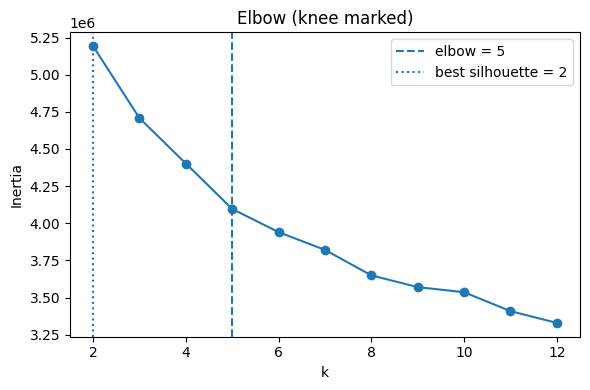

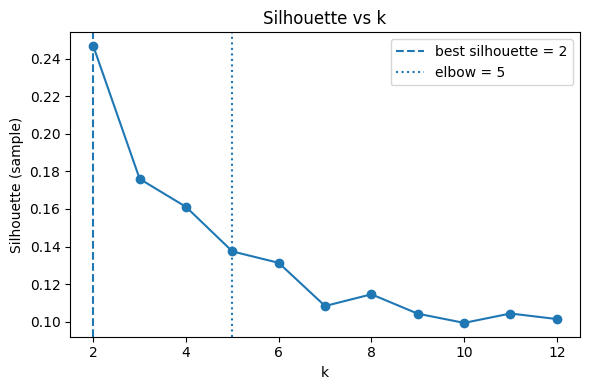


[ELBOW] Trained K-means with k=5 | Inertia=4,122,230 | Silhouette(sample)=0.1332


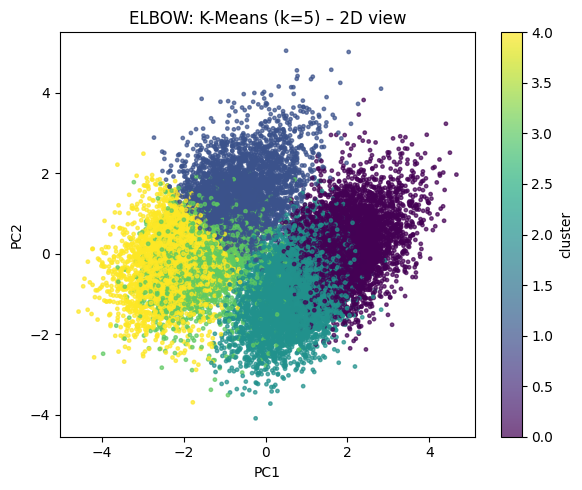


[ELBOW] Crosstab: smoking vs cluster (row-normalized)
col_0                 0      1      2      3      4
smk_stat_type_cd                                   
0.0               0.101  0.290  0.170  0.174  0.265
0.5               0.443  0.026  0.476  0.029  0.026
1.0               0.477  0.028  0.428  0.045  0.023

[ELBOW] Crosstab: drinking vs cluster (row-normalized)
col_0       0      1      2      3      4
drk_yn                                   
0.0     0.112  0.286  0.227  0.137  0.238
1.0     0.369  0.092  0.329  0.106  0.105

[SILHOUETTE] Trained K-means with k=2 | Inertia=5,191,270 | Silhouette(sample)=0.2469


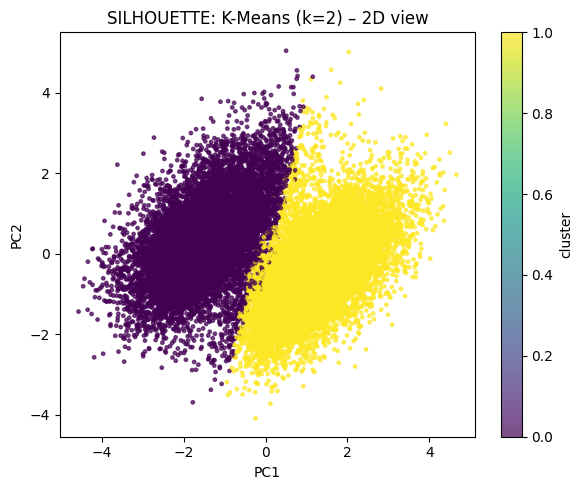


[SILHOUETTE] Crosstab: smoking vs cluster (row-normalized)
col_0                 0      1
smk_stat_type_cd              
0.0               0.716  0.284
0.5               0.085  0.915
1.0               0.093  0.907

[SILHOUETTE] Crosstab: drinking vs cluster (row-normalized)
col_0       0      1
drk_yn              
0.0     0.650  0.350
1.0     0.298  0.702


In [19]:
# === K-MEANS: elbow (normalized knee) vs best silhouette — visuals + smoking/drinking crosstabs ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ---------------- 0) Load & prepare ----------------
CSV_PATH = "drinking_df_ready_for_clustering_v3.csv"
df = pd.read_csv(CSV_PATH)

# Exclude behavior columns from clustering features
cols_exclude = ["smk_stat_type_cd", "drk_yn"]
feature_candidates = [c for c in df.columns if c not in cols_exclude]
X_num = df[feature_candidates].select_dtypes(include=[np.number])
feature_names = X_num.columns.tolist()

imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X_num)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# ---------------- 1) Sampling for plotting + PCA (visualization only) ----------------
rng = np.random.default_rng(42)
plot_n = min(20_000, len(X_scaled))
plot_idx = rng.choice(len(X_scaled), size=plot_n, replace=False)

pca = PCA(n_components=2, random_state=42)
X2_plot = pca.fit_transform(X_scaled[plot_idx])  # ONLY for 2D visuals

# ---------------- 2) Scan k: inertia on FULL data, silhouette on SAMPLE ----------------
sil_idx = rng.choice(len(X_scaled), size=min(20_000, len(X_scaled)), replace=False)
X_sil = X_scaled[sil_idx]

k_list = list(range(2, 13))
inertias, sils = [], []

for k in k_list:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=50_000, n_init=10)
    km.fit(X_scaled)                         # full data for stable inertia
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_sil, km.predict(X_sil)))  # fast & comparable

# ---- Elbow via normalized max-distance to the chord (no external deps) ----
x = np.array(k_list, dtype=float)
y = np.array(inertias, dtype=float)

# normalize both axes to [0,1] to reduce bias
xs = (x - x.min()) / (x.max() - x.min())
ys = (y - y.min()) / (y.max() - y.min())

p1, p2 = np.array([xs[0], ys[0]]), np.array([xs[-1], ys[-1]])
v = p2 - p1
dist_norm = np.abs(np.cross(v, np.column_stack([xs, ys]) - p1)) / np.linalg.norm(v)
k_elbow = int(x[np.argmax(dist_norm)])

# Best silhouette k
k_sil = int(x[np.nanargmax(sils)])

print("\n=== K selection ===")
print("Elbow (normalized distance): k =", k_elbow)
print(f"Best silhouette: k = {k_sil}  (score = {np.nanmax(sils):.4f})")

# Curves with both ks marked
plt.figure(figsize=(6,4))
plt.plot(k_list, inertias, marker="o")
plt.axvline(k_elbow, ls="--", label=f"elbow = {k_elbow}")
plt.axvline(k_sil,   ls=":",  label=f"best silhouette = {k_sil}")
plt.xlabel("k"); plt.ylabel("Inertia"); plt.title("Elbow (knee marked)")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(k_list, sils, marker="o")
plt.axvline(k_sil,   ls="--", label=f"best silhouette = {k_sil}")
plt.axvline(k_elbow, ls=":",  label=f"elbow = {k_elbow}")
plt.xlabel("k"); plt.ylabel("Silhouette (sample)")
plt.title("Silhouette vs k")
plt.legend(); plt.tight_layout(); plt.show()

# ---------------- 3) Train BOTH models (elbow-k and silhouette-k) ----------------
def train_and_report(k, tag):
    km = MiniBatchKMeans(n_clusters=k, random_state=777, batch_size=50_000, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_sil, km.predict(X_sil))
    print(f"\n[{tag}] Trained K-means with k={k} | Inertia={km.inertia_:,.0f} | Silhouette(sample)={sil:.4f}")

    # 2D cluster plot (PCA is just for visualization)
    lbl_plot = labels[plot_idx]
    plt.figure(figsize=(6,5))
    sc = plt.scatter(X2_plot[:,0], X2_plot[:,1], c=lbl_plot, s=6, alpha=0.7)
    plt.title(f"{tag}: K-Means (k={k}) – 2D view")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.colorbar(sc, label="cluster")
    plt.tight_layout(); plt.show()

    # Row-normalized crosstabs (exactly as requested)
    if "smk_stat_type_cd" in df.columns:
        print(f"\n[{tag}] Crosstab: smoking vs cluster (row-normalized)")
        print(pd.crosstab(df["smk_stat_type_cd"], labels, normalize="index").round(3))
    if "drk_yn" in df.columns:
        print(f"\n[{tag}] Crosstab: drinking vs cluster (row-normalized)")
        print(pd.crosstab(df["drk_yn"], labels, normalize="index").round(3))

    return labels

labels_elbow = train_and_report(k_elbow, "ELBOW")
if k_sil != k_elbow:
    labels_sil = train_and_report(k_sil, "SILHOUETTE")
else:
    print("\n[Info] Elbow k equals best silhouette k — single model shown.")



[BMI] Added 'bmi_group' categorical variable.

=== ELBOW: Cluster Health & Lifestyle Summary ===

[ELBOW] Smoking vs cluster (row-normalized)
cluster               0      1      2      3      4
smk_stat_type_cd                                   
0.0               0.099  0.333  0.168  0.094  0.307
0.5               0.058  0.037  0.463  0.414  0.028
1.0               0.036  0.041  0.447  0.441  0.034

[ELBOW] Drinking vs cluster (row-normalized)
cluster      0      1      2      3      4
drk_yn                                    
0.0      0.111  0.279  0.219  0.103  0.288
1.0      0.047  0.160  0.338  0.343  0.113

[ELBOW] BMI group vs cluster (row-normalized)
cluster        0      1      2      3    4
bmi_group                                 
Low        0.078  0.219  0.279  0.224  0.2

[ELBOW] Approx. 'cluster health index' (higher = healthier):
cluster
0    0.93
3    0.85
4    0.10
2   -0.39
1   -1.50
dtype: float64


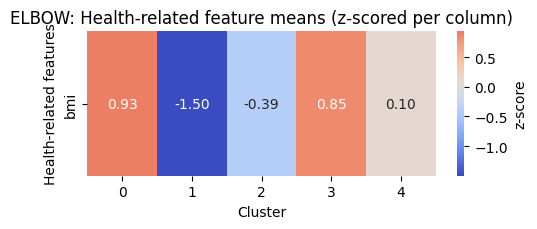


=== SILHOUETTE: Cluster Health & Lifestyle Summary ===

[SILHOUETTE] Smoking vs cluster (row-normalized)
cluster               0      1
smk_stat_type_cd              
0.0               0.714  0.286
0.5               0.084  0.916
1.0               0.092  0.908

[SILHOUETTE] Drinking vs cluster (row-normalized)
cluster      0      1
drk_yn               
0.0      0.648  0.352
1.0      0.297  0.703

[SILHOUETTE] BMI group vs cluster (row-normalized)
cluster        0      1
bmi_group              
Low        0.472  0.528

[SILHOUETTE] Approx. 'cluster health index' (higher = healthier):
cluster
1    0.71
0   -0.71
dtype: float64


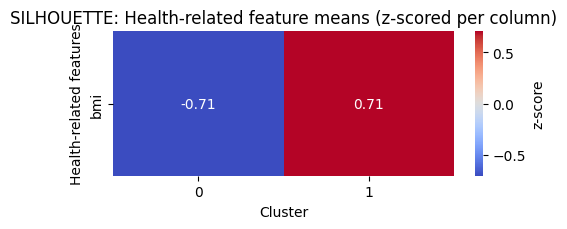

In [17]:
# === Cluster health & lifestyle profiling ===
import seaborn as sns
from matplotlib import pyplot as plt

def categorize_bmi(df):
    """Add BMI categories according to WHO cutoffs."""
    if "bmi" in df.columns:
        bins = [0, 18.5, 25, 30, np.inf]
        labels = ["Low", "Normal", "Overweight", "Obese"]
        df["bmi_group"] = pd.cut(df["bmi"], bins=bins, labels=labels)
        print("[BMI] Added 'bmi_group' categorical variable.")
    return df

def cluster_health_profile(df, labels, tag="MODEL"):
    """
    Summarize health and lifestyle indicators per cluster.
    Creates numeric heatmaps for health-related variables,
    and prints categorical crosstabs for smoking, drinking, BMI.
    """
    print(f"\n=== {tag}: Cluster Health & Lifestyle Summary ===")

    df_local = df.copy()
    df_local["cluster"] = labels

    # --- Behavior crosstabs (categorical) ---
    if "smk_stat_type_cd" in df_local.columns:
        print(f"\n[{tag}] Smoking vs cluster (row-normalized)")
        print(pd.crosstab(df_local["smk_stat_type_cd"], df_local["cluster"], normalize="index").round(3))

    if "drk_yn" in df_local.columns:
        print(f"\n[{tag}] Drinking vs cluster (row-normalized)")
        print(pd.crosstab(df_local["drk_yn"], df_local["cluster"], normalize="index").round(3))

    if "bmi_group" in df_local.columns:
        print(f"\n[{tag}] BMI group vs cluster (row-normalized)")
        print(pd.crosstab(df_local["bmi_group"], df_local["cluster"], normalize="index").round(3))

    # --- Identify health-related numeric features automatically ---
    health_keywords = ["health", "bmi", "activity", "exercise", "sleep", "mental", "stress", "nutrition", "diet"]
    health_cols = [
        c for c in df_local.select_dtypes(include=[np.number]).columns
        if any(k in c.lower() for k in health_keywords)
    ]
    if not health_cols:
        print(f"\n[{tag}] No numeric health-related columns detected.")
        return

    # --- Compute mean per cluster ---
    health_means = df_local.groupby("cluster")[health_cols].mean()

    # --- Standardize (z-score) for visual comparison ---
    z_health = (health_means - health_means.mean()) / (health_means.std() + 1e-9)

    # --- Rank clusters by average z across health vars ---
    cluster_health_index = z_health.mean(axis=1).sort_values(ascending=False)
    print(f"\n[{tag}] Approx. 'cluster health index' (higher = healthier):")
    print(cluster_health_index.round(2))

    # --- Visualize heatmap ---
    plt.figure(figsize=(min(12, 1.2*len(health_cols)+4), 0.4*len(health_cols)+2))
    sns.heatmap(z_health.T, cmap="coolwarm", center=0, annot=True, fmt=".2f", cbar_kws={"label": "z-score"})
    plt.title(f"{tag}: Health-related feature means (z-scored per column)")
    plt.xlabel("Cluster")
    plt.ylabel("Health-related features")
    plt.tight_layout()
    plt.show()

# --- Prepare & run ---
df = categorize_bmi(df)

# Run for ELBOW model
cluster_health_profile(df, labels_elbow, tag="ELBOW")

# Run for SILHOUETTE model if it exists
if "labels_sil" in locals():
    cluster_health_profile(df, labels_sil, tag="SILHOUETTE")




=== K selection diagnostics ===
 k    inertia  rel_impr_%_vs_prev
 2 4362418.60                 NaN
 3 3949455.29                9.47
 4 3562575.53                9.80
 5 3488781.32                2.07
 6 3229012.75                7.45
 7 3123950.85                3.25
 8 2956475.93                5.36
 9 2894661.56                2.09
10 2761565.34                4.60
11 2685954.88                2.74
12 2602920.06                3.09

Kneedle elbow: k = 6
Normalized-distance elbow: k = 4
Threshold rule (5.0%): k = 5
Best silhouette (sample): k = 2  (score = 0.2761)

[Chosen k] Using: k = 6 (Kneedle if available, else normalized-distance)


C:\Users\hanev\AppData\Local\Temp\ipykernel_1380\3260378288.py:76: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist_norm = np.abs(np.cross(v, np.column_stack([xs, ys]) - p1)) / np.linalg.norm(v)


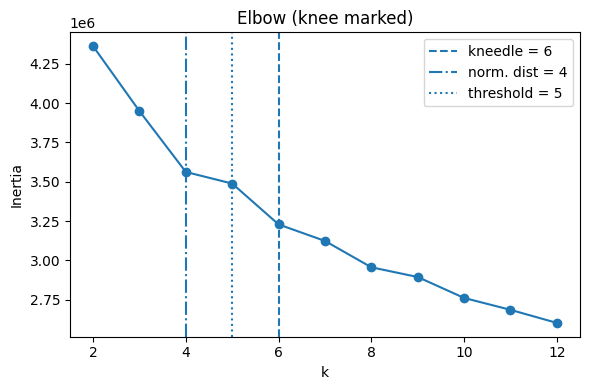

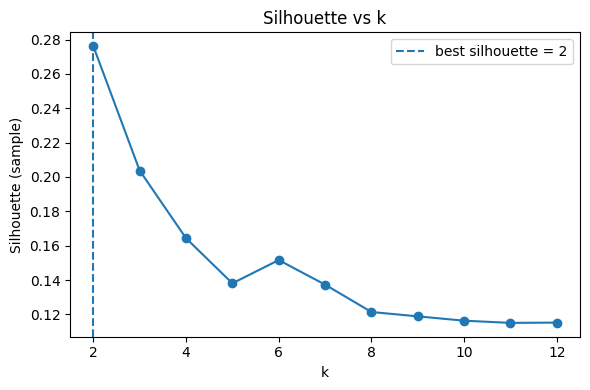


[Final model] k=6 | Inertia=3,203,970 | Silhouette(sample)=0.1498


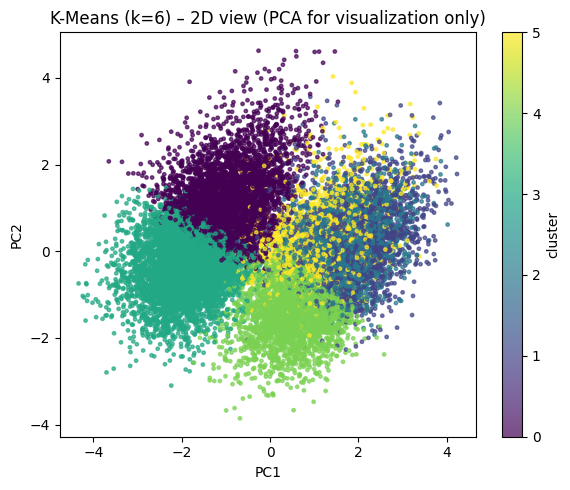

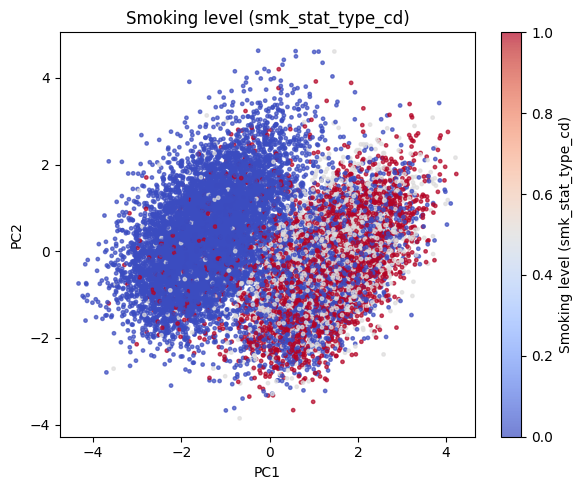

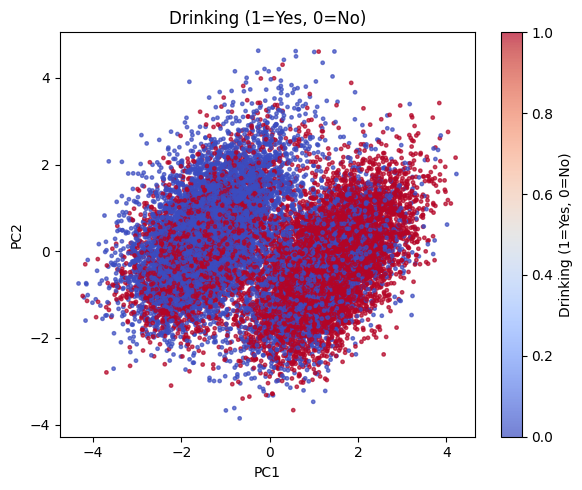


Cluster sizes: {np.int32(0): np.int64(187101), np.int32(1): np.int64(107903), np.int32(2): np.int64(135310), np.int32(3): np.int64(218716), np.int32(4): np.int64(139673), np.int32(5): np.int64(88315)}


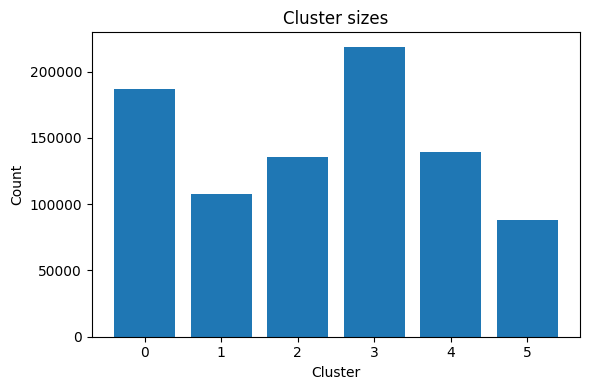


=== Behavior by cluster (means) ===
         smk_mean  drk_mean
cluster                    
0           0.044     0.256
1           0.613     0.832
2           0.513     0.649
3           0.049     0.359
4           0.488     0.618
5           0.449     0.564


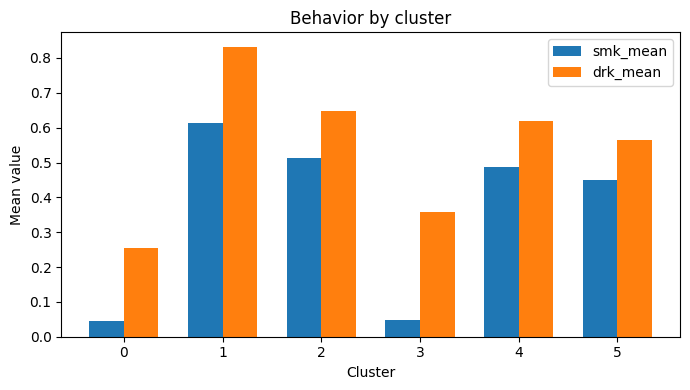


Crosstab: smoking vs cluster (row-normalized)
col_0                 0      1      2      3      4      5
smk_stat_type_cd                                          
0.0               0.329  0.048  0.083  0.382  0.098  0.061
0.5               0.028  0.210  0.274  0.038  0.244  0.207
1.0               0.033  0.269  0.261  0.042  0.266  0.128


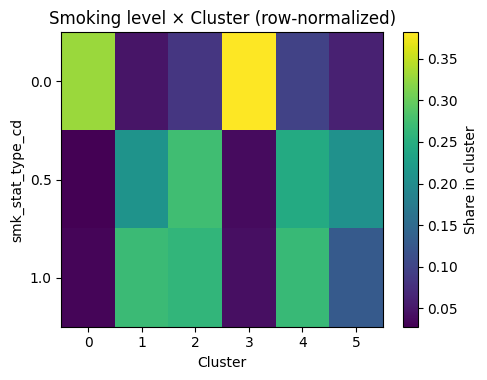


Crosstab: drinking (1=Yes,0=No) vs cluster (row-normalized)
col_0       0      1      2      3      4      5
drk_yn                                          
0.0     0.319  0.042  0.109  0.321  0.122  0.088
1.0     0.109  0.204  0.199  0.178  0.196  0.113


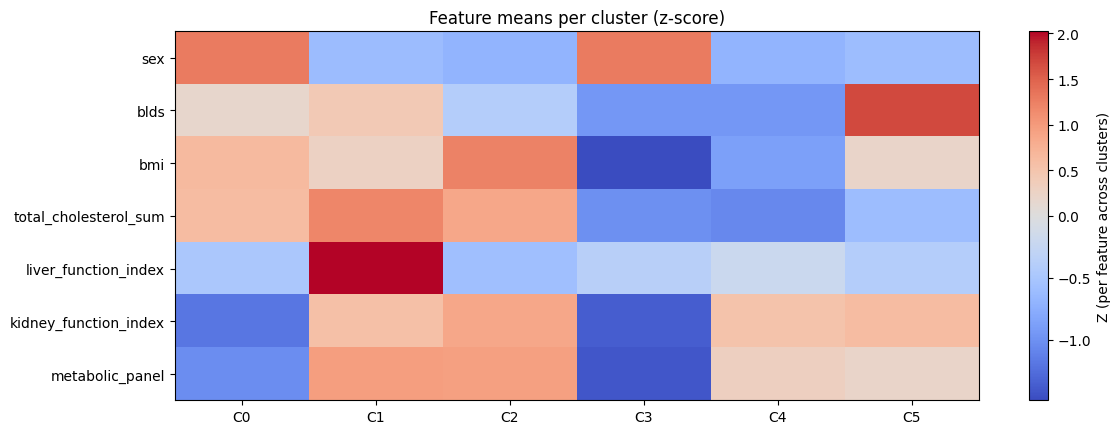


>>> Final model trained with k = 6


In [37]:
# === K-MEANS with robust elbow (Kneedle), silhouette check, and full reporting ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from matplotlib.colors import TwoSlopeNorm

# ---------------- 0) Load & prepare ----------------
CSV_PATH = "drinking_df_ready_for_clustering_v3.csv"
df = pd.read_csv(CSV_PATH)

# Features (exclude behavior)
cols_exclude = ["smk_stat_type_cd", "drk_yn"]
feature_candidates = [c for c in df.columns if c not in cols_exclude]
X_num = df[feature_candidates].select_dtypes(include=[np.number])
feature_names = X_num.columns.tolist()

imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X_num)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# Behavior columns (optional)
def _drink_to_num(s):
    if s is None: return None
    if s.dtype == object: return s.map({"Y":1, "N":0}).fillna(0).astype(float)
    return s.astype(float)

smk_full = df["smk_stat_type_cd"] if "smk_stat_type_cd" in df.columns else None
drk_full = _drink_to_num(df["drk_yn"]) if "drk_yn" in df.columns else None

# ---------------- 1) Sampling for plotting + PCA (visualization only) ----------------
rng = np.random.default_rng(42)
plot_n = min(20_000, len(X_scaled))
plot_idx = rng.choice(len(X_scaled), size=plot_n, replace=False)

pca = PCA(n_components=2, random_state=42)
X2_plot = pca.fit_transform(X_scaled[plot_idx])  # ONLY for 2D visuals

# ---------------- 2) Choose k: compute inertia on FULL data, silhouette on sample -----
sil_idx = rng.choice(len(X_scaled), size=min(20_000, len(X_scaled)), replace=False)
X_sil = X_scaled[sil_idx]

k_list = list(range(2, 13))
inertias, sils = [], []

# Inertia on FULL dataset for stability
for k in k_list:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=50_000, n_init=10)
    km.fit(X_scaled)                  # <--- FULL data
    inertias.append(km.inertia_)
    # silhouette on sample (fast, comparable)
    sils.append(silhouette_score(X_sil, km.predict(X_sil)))

# ---- Knee via Kneedle (robust), with normalized-distance fallback ----
kneedle_k = None
try:
    from kneed import KneeLocator
    kn = KneeLocator(k_list, inertias, curve="convex", direction="decreasing", S=1.0)
    kneedle_k = int(kn.elbow) if kn.elbow is not None else None
except Exception:
    kneedle_k = None

# Fallback: normalized max-distance to chord (less biased than raw)
x = np.array(k_list, dtype=float)
y = np.array(inertias, dtype=float)
xs = (x - x.min()) / (x.max() - x.min())
ys = (y - y.min()) / (y.max() - y.min())
p1, p2 = np.array([xs[0], ys[0]]), np.array([xs[-1], ys[-1]])
v = p2 - p1
dist_norm = np.abs(np.cross(v, np.column_stack([xs, ys]) - p1)) / np.linalg.norm(v)
normdist_k = int(x[np.argmax(dist_norm)])

# Relative inertia improvement table
rel_impr = [np.nan] + [(inertias[i-1] - inertias[i]) / inertias[i-1] * 100.0 for i in range(1, len(inertias))]
impr_tbl = pd.DataFrame({"k": k_list, "inertia": inertias, "rel_impr_%_vs_prev": rel_impr})

# Threshold heuristic
threshold = 5.0
below = np.where(np.array(rel_impr[1:]) < threshold)[0]
k_by_threshold = int(k_list[below[0]+1]) if len(below) > 0 else k_list[-1]

# Best silhouette (on sample)
best_sil_k = int(x[np.nanargmax(sils)]) if np.isfinite(np.nanmax(sils)) else (kneedle_k or normdist_k)

# Final choice: prefer Kneedle if available, else normalized distance
final_k = kneedle_k if kneedle_k is not None else normdist_k

print("\n=== K selection diagnostics ===")
print(impr_tbl.round(2).to_string(index=False))
print(f"\nKneedle elbow: k = {kneedle_k}")
print(f"Normalized-distance elbow: k = {normdist_k}")
print(f"Threshold rule ({threshold:.1f}%): k = {k_by_threshold}")
print(f"Best silhouette (sample): k = {best_sil_k}  (score = {np.nanmax(sils):.4f})")
print(f"\n[Chosen k] Using: k = {final_k} (Kneedle if available, else normalized-distance)")

# Plots: Elbow & Silhouette with all markers
plt.figure(figsize=(6,4))
plt.plot(k_list, inertias, marker="o")
if kneedle_k is not None:
    plt.axvline(kneedle_k, ls="--", label=f"kneedle = {kneedle_k}")
plt.axvline(normdist_k, ls="-.", label=f"norm. dist = {normdist_k}")
plt.axvline(k_by_threshold, ls=":", label=f"threshold = {k_by_threshold}")
plt.xlabel("k"); plt.ylabel("Inertia"); plt.title("Elbow (knee marked)")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(k_list, sils, marker="o")
plt.axvline(best_sil_k, ls="--", label=f"best silhouette = {best_sil_k}")
plt.xlabel("k"); plt.ylabel("Silhouette (sample)")
plt.title("Silhouette vs k")
plt.legend(); plt.tight_layout(); plt.show()

# ---------------- 3) Train final K-means ----------------
kmeans = MiniBatchKMeans(n_clusters=final_k, random_state=777, batch_size=50_000, n_init=20)
labels_km = kmeans.fit_predict(X_scaled)
labels_sil = kmeans.predict(X_sil)
final_sil_score = silhouette_score(X_sil, labels_sil)

print(f"\n[Final model] k={final_k} | Inertia={kmeans.inertia_:,.0f} | Silhouette(sample)={final_sil_score:.4f}")

# ---------------- 4) Visualizations (English) ----------------
def plot_clusters(labels, title):
    lbl = labels[plot_idx]
    plt.figure(figsize=(6,5))
    sc = plt.scatter(X2_plot[:,0], X2_plot[:,1], c=lbl, s=6, alpha=0.7)
    plt.title(title); plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.colorbar(sc, label="cluster"); plt.tight_layout(); plt.show()

def plot_by_behavior(vals, title, cmap="coolwarm"):
    if vals is None: 
        return
    v = pd.Series(vals).iloc[plot_idx].fillna(0).to_numpy()
    plt.figure(figsize=(6,5))
    sc = plt.scatter(X2_plot[:,0], X2_plot[:,1], c=v, s=6, alpha=0.7, cmap=cmap)
    plt.title(title); plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.colorbar(sc, label=title); plt.tight_layout(); plt.show()

# 4a) Cluster scatter
plot_clusters(labels_km, f"K-Means (k={final_k}) – 2D view (PCA for visualization only)")

# 4b) Smoking / Drinking overlays
plot_by_behavior(smk_full, "Smoking level (smk_stat_type_cd)")
plot_by_behavior(drk_full, "Drinking (1=Yes, 0=No)")

# 4c) Cluster sizes
unique, counts = np.unique(labels_km, return_counts=True)
sizes = dict(zip(unique, counts))
print("\nCluster sizes:", sizes)
plt.figure(figsize=(6,4))
plt.bar(list(sizes.keys()), list(sizes.values()))
plt.xticks(range(final_k)); plt.ylabel("Count"); plt.xlabel("Cluster")
plt.title("Cluster sizes"); plt.tight_layout(); plt.show()

# 4d) Behavior by cluster (means)
beh_cols = {}
if smk_full is not None: beh_cols["smk_mean"] = smk_full
if drk_full is not None: beh_cols["drk_mean"] = drk_full
if beh_cols:
    summary = pd.DataFrame({"cluster": labels_km, **beh_cols}).groupby("cluster").mean(numeric_only=True).round(3)
    print("\n=== Behavior by cluster (means) ===")
    print(summary)
    plt.figure(figsize=(7,4))
    for i, col in enumerate(summary.columns, 1):
        plt.bar(summary.index + (i-1)*0.35, summary[col].values, width=0.35, label=col)
    plt.xticks(summary.index + 0.35/2, summary.index)
    plt.xlabel("Cluster"); plt.ylabel("Mean value"); plt.title("Behavior by cluster")
    plt.legend(); plt.tight_layout(); plt.show()

# 4e) Smoking crosstab heatmap + printed tables
if smk_full is not None:
    ct = pd.crosstab(df["smk_stat_type_cd"], labels_km, normalize="index").reindex(sorted(df["smk_stat_type_cd"].dropna().unique()))
    print("\nCrosstab: smoking vs cluster (row-normalized)")
    print(pd.crosstab(df["smk_stat_type_cd"], labels_km, normalize="index").round(3))
    plt.figure(figsize=(5,3 + 0.3*len(ct)))
    im = plt.imshow(ct.values, aspect="auto", cmap="viridis")
    plt.colorbar(im, label="Share in cluster")
    plt.yticks(range(len(ct.index)), [str(v) for v in ct.index])
    plt.xticks(range(final_k), [str(i) for i in range(final_k)])
    plt.xlabel("Cluster"); plt.ylabel("smk_stat_type_cd")
    plt.title("Smoking level × Cluster (row-normalized)")
    plt.tight_layout(); plt.show()

# 4f) Drinking crosstab (printed)
if drk_full is not None:
    print("\nCrosstab: drinking (1=Yes,0=No) vs cluster (row-normalized)")
    print(pd.crosstab(drk_full, labels_km, normalize="index").round(3))

# 4g) Feature means per cluster (z-score across clusters)
X_df = pd.DataFrame(X_scaled, columns=feature_names)
means = X_df.assign(cluster=labels_km).groupby("cluster").mean()
M = ((means - means.mean(axis=0)) / (means.std(axis=0) + 1e-9)).T
plt.figure(figsize=(min(12, 1.2*final_k + 5), 0.35*len(feature_names) + 2))
norm = TwoSlopeNorm(vcenter=0.0)
im = plt.imshow(M.values, aspect="auto", cmap="coolwarm", norm=norm)
plt.colorbar(im, label="Z (per feature across clusters)")
plt.yticks(range(len(M.index)), M.index)
plt.xticks(range(final_k), [f"C{i}" for i in range(final_k)])
plt.title("Feature means per cluster (z-score)")
plt.tight_layout(); plt.show()

# 4h) If k=2: boxplots for top discriminative features
if final_k == 2:
    grp0, grp1 = X_df[labels_km==0], X_df[labels_km==1]
    diffs = (grp0.mean() - grp1.mean()).abs().sort_values(ascending=False)
    top_feats = list(diffs.head(min(6, len(diffs))).index)
    rows = int(np.ceil(len(top_feats) / 3)) or 1
    plt.figure(figsize=(15, 4*rows))
    for i, feat in enumerate(top_feats, 1):
        plt.subplot(rows, 3, i)
        plt.boxplot([grp0[feat].values, grp1[feat].values], labels=["C0","C1"], showfliers=False)
        plt.title(f"{feat}  |  |Δμ| = {diffs[feat]:.2f}")
    plt.suptitle("Top features separating the two clusters (boxplots, scaled values)")
    plt.tight_layout(rect=[0,0,1,0.96]); plt.show()

print("\n>>> Final model trained with k =", final_k)



=== K selection (comparison) ===
Elbow (knee): k = 4
Best silhouette: k = 2 (score = 0.2784)
Best Calinski–Harabasz: k = 2 (score = 357280)
Best Davies–Bouldin: k = 2 (score = 1.4743)
→ Majority vote: k = 2

Top-5 rows of metrics:
   k   WSS/inertia  silhouette  calinski_harabasz  davies_bouldin
0  2  4.362419e+06    0.278403      357279.868130        1.474307
1  3  3.949455e+06    0.204631      244154.658789        1.827091
2  4  3.562576e+06    0.164428      211812.878316        1.962950
3  5  3.488781e+06    0.138615      170527.724853        1.962611
4  6  3.229013e+06    0.151443      158522.826166        1.972427


C:\Users\hanev\AppData\Local\Temp\ipykernel_1380\743263567.py:30: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist_norm = np.abs(np.cross(v, np.column_stack([xs, ys]) - p1)) / np.linalg.norm(v)


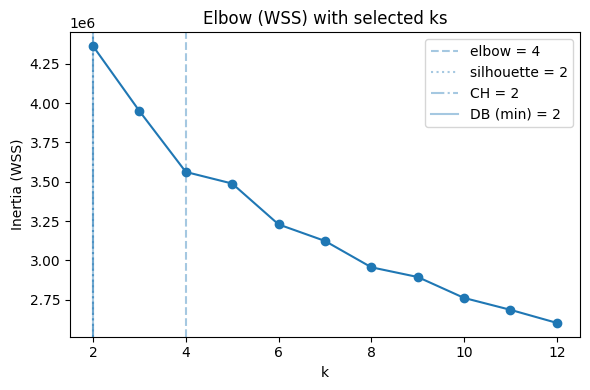

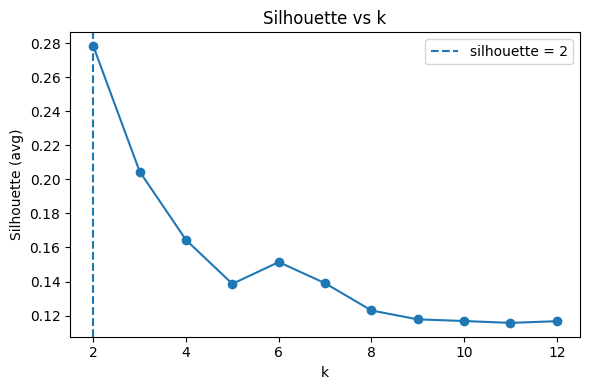

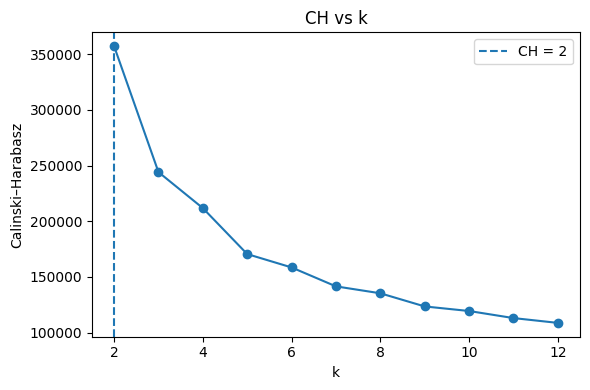

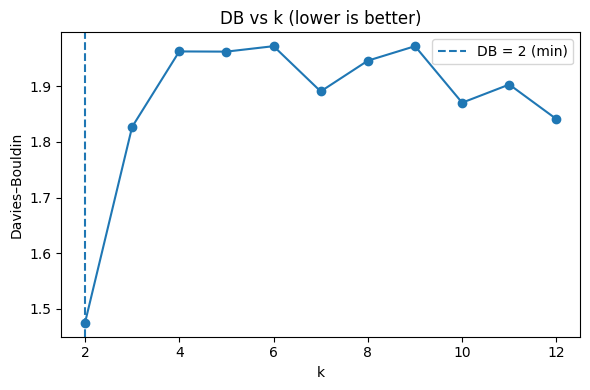


[ELBOW] K=4 | Inertia=3,580,124 | Silhouette(sample)=0.1677


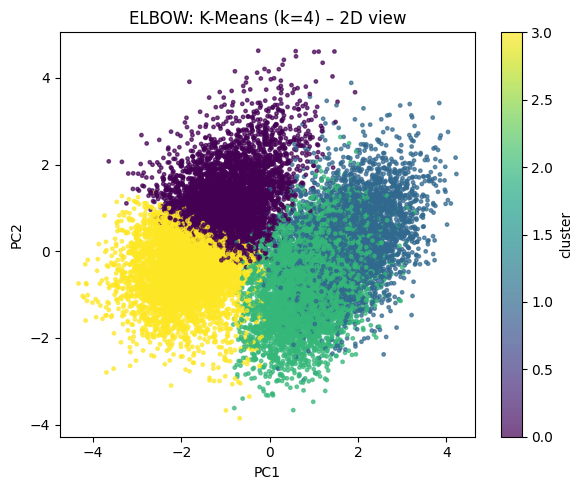


[ELBOW] Crosstab: smoking vs cluster (row-normalized)
col_0                 0      1      2      3
smk_stat_type_cd                            
0.0               0.346  0.084  0.191  0.378
0.5               0.032  0.375  0.547  0.046
1.0               0.036  0.437  0.475  0.052

[ELBOW] Crosstab: drinking vs cluster (row-normalized)
col_0       0      1      2      3
drk_yn                            
0.0     0.337  0.089  0.254  0.320
1.0     0.115  0.330  0.373  0.182

[SILHOUETTE] K=2 | Inertia=4,362,271 | Silhouette(sample)=0.2784


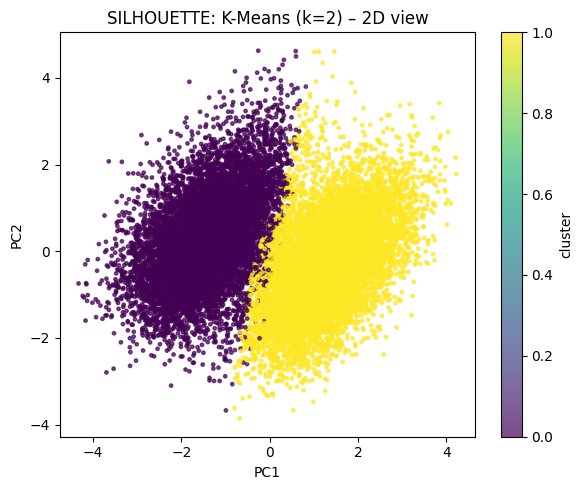


[SILHOUETTE] Crosstab: smoking vs cluster (row-normalized)
col_0                 0      1
smk_stat_type_cd              
0.0               0.720  0.280
0.5               0.079  0.921
1.0               0.086  0.914

[SILHOUETTE] Crosstab: drinking vs cluster (row-normalized)
col_0       0      1
drk_yn              
0.0     0.652  0.348
1.0     0.296  0.704

[Info] Majority-k overlapper med elbow/silhouette — ekstra modell ikke nødvendig.


In [46]:
# ---------------- 2) Scan k: inertia (WSS) on FULL data + Sil/CH/DB ----------------
sil_idx = rng.choice(len(X_scaled), size=min(20_000, len(X_scaled)), replace=False)
X_sil = X_scaled[sil_idx]

k_list = list(range(2, 13))
inertias, sils, chs, dbs = [], [], [], []

for k in k_list:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=50_000, n_init=10)
    labels_full = km.fit_predict(X_scaled)           # full data for inertia, CH, DB
    inertias.append(km.inertia_)

    # Silhouette på et sample for fart (samme modell, predikér labels for sample)
    labels_sil = km.predict(X_sil)
    sils.append(silhouette_score(X_sil, labels_sil))

    # CH/DB på full data (krever labels og X)
    from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
    chs.append(calinski_harabasz_score(X_scaled, labels_full))
    dbs.append(davies_bouldin_score(X_scaled, labels_full))

# ---- Elbow via normalized max-distance to chord (robust knee) ----
x = np.array(k_list, dtype=float)
y = np.array(inertias, dtype=float)

xs = (x - x.min()) / (x.max() - x.min())
ys = (y - y.min()) / (y.max() - y.min())
p1, p2 = np.array([xs[0], ys[0]]), np.array([xs[-1], ys[-1]])
v = p2 - p1
dist_norm = np.abs(np.cross(v, np.column_stack([xs, ys]) - p1)) / np.linalg.norm(v)
k_elbow = int(x[np.argmax(dist_norm)])

# Best k fra hver indeks
k_sil = int(x[np.nanargmax(sils)])
k_ch  = int(x[np.nanargmax(chs)])
k_db  = int(x[np.nanargmin(dbs)])  # lavere DB er bedre

# ---- Sammendrag og majority-vote ----
summary = pd.DataFrame({
    "k": k_list,
    "WSS/inertia": inertias,
    "silhouette": sils,
    "calinski_harabasz": chs,
    "davies_bouldin": dbs
})

candidates = [k_elbow, k_sil, k_ch, k_db]
vals, counts = np.unique(candidates, return_counts=True)
k_majority = int(vals[np.argmax(counts)])

print("\n=== K selection (comparison) ===")
print(f"Elbow (knee): k = {k_elbow}")
print(f"Best silhouette: k = {k_sil} (score = {np.nanmax(sils):.4f})")
print(f"Best Calinski–Harabasz: k = {k_ch} (score = {np.nanmax(chs):.0f})")
print(f"Best Davies–Bouldin: k = {k_db} (score = {np.nanmin(dbs):.4f})")
print(f"→ Majority vote: k = {k_majority}")
print("\nTop-5 rows of metrics:")
print(summary.head())

# ---- Plotter med markeringer ----
plt.figure(figsize=(6,4))
plt.plot(k_list, inertias, marker="o")
for kk, ls, lab in [(k_elbow, "--", "elbow"),
                    (k_sil, ":",  "silhouette"),
                    (k_ch,  "-.", "CH"),
                    (k_db,  "-",  "DB (min)")]:
    plt.axvline(kk, ls=ls, alpha=0.4, label=f"{lab} = {kk}")
plt.xlabel("k"); plt.ylabel("Inertia (WSS)"); plt.title("Elbow (WSS) with selected ks")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(k_list, sils, marker="o"); plt.axvline(k_sil, ls="--", label=f"silhouette = {k_sil}")
plt.xlabel("k"); plt.ylabel("Silhouette (avg)"); plt.title("Silhouette vs k")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(k_list, chs, marker="o"); plt.axvline(k_ch, ls="--", label=f"CH = {k_ch}")
plt.xlabel("k"); plt.ylabel("Calinski–Harabasz"); plt.title("CH vs k")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(k_list, dbs, marker="o"); plt.axvline(k_db, ls="--", label=f"DB = {k_db} (min)")
plt.xlabel("k"); plt.ylabel("Davies–Bouldin"); plt.title("DB vs k (lower is better)")
plt.legend(); plt.tight_layout(); plt.show()

# ---------------- 3) Train modeller for elbow, silhouette og majority ----------------
def train_and_report(k, tag):
    km = MiniBatchKMeans(n_clusters=k, random_state=777, batch_size=50_000, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_sil, km.predict(X_sil))
    print(f"\n[{tag}] K={k} | Inertia={km.inertia_:,.0f} | Silhouette(sample)={sil:.4f}")

    # 2D cluster plot (PCA kun for visualisering)
    lbl_plot = labels[plot_idx]
    plt.figure(figsize=(6,5))
    sc = plt.scatter(X2_plot[:,0], X2_plot[:,1], c=lbl_plot, s=6, alpha=0.7)
    plt.title(f"{tag}: K-Means (k={k}) – 2D view")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.colorbar(sc, label="cluster")
    plt.tight_layout(); plt.show()

    # Krysstabeller for tolkning
    if "smk_stat_type_cd" in df.columns:
        print(f"\n[{tag}] Crosstab: smoking vs cluster (row-normalized)")
        print(pd.crosstab(df["smk_stat_type_cd"], labels, normalize="index").round(3))
    if "drk_yn" in df.columns:
        print(f"\n[{tag}] Crosstab: drinking vs cluster (row-normalized)")
        print(pd.crosstab(df["drk_yn"], labels, normalize="index").round(3))
    return labels

labels_elbow = train_and_report(k_elbow, "ELBOW")
if k_sil != k_elbow:
    labels_sil = train_and_report(k_sil, "SILHOUETTE")

if k_majority not in {k_elbow, k_sil}:
    labels_maj = train_and_report(k_majority, "MAJORITY")
else:
    print("\n[Info] Majority-k overlapper med elbow/silhouette — ekstra modell ikke nødvendig.")



In [47]:
import numpy as np, pandas as pd
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.utils import resample
from itertools import combinations
from scipy.spatial.distance import cdist, pdist, squareform

rng = np.random.default_rng(42)
k_list = list(range(2, 13))

def dunn_index(X, labels):
    # Kompakt implementasjon uten eksterne pakker
    D = squareform(pdist(X))  # NxN
    clusters = [np.where(labels==c)[0] for c in np.unique(labels)]
    # Min inter-cluster avstand
    inter = np.inf
    for i, j in combinations(range(len(clusters)), 2):
        inter = min(inter, D[np.ix_(clusters[i], clusters[j])].min())
    # Max intra-cluster diameter
    intra = 0.0
    for ids in clusters:
        if len(ids) > 1:
            intra = max(intra, D[np.ix_(ids, ids)].max())
    return inter / intra if intra > 0 else np.nan

def gap_statistic(X, k, B=50, random_state=42):
    # Uniform referanse i hyperboks
    rs = np.random.default_rng(random_state)
    mins = X.min(axis=0); maxs = X.max(axis=0)
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=50_000, n_init=10)
    labels = km.fit_predict(X)
    Wk = np.sum((X - km.cluster_centers_[labels])**2)

    Wk_refs = []
    for b in range(B):
        Xb = rs.uniform(mins, maxs, size=X.shape)
        kmb = MiniBatchKMeans(n_clusters=k, random_state=42+b, batch_size=50_000, n_init=10)
        lb = kmb.fit_predict(Xb)
        Wkb = np.sum((Xb - kmb.cluster_centers_[lb])**2)
        Wk_refs.append(np.log(Wkb))
    gap = np.mean(Wk_refs) - np.log(Wk)
    sk = np.std(Wk_refs, ddof=1) * np.sqrt(1 + 1/B)
    return gap, sk

metrics = []
for k in k_list:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=50_000, n_init=10)
    labels = km.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)
    dunn = dunn_index(X_scaled, labels)

    gap, sk = gap_statistic(X_scaled, k, B=50, random_state=123)

    metrics.append(dict(k=k, inertia=km.inertia_, silhouette=sil, ch=ch, db=db, dunn=dunn, gap=gap, gap_se=sk))

summary = pd.DataFrame(metrics)

# Velg k per indeks
k_elbow = int(summary.assign(x=(summary['k']-summary['k'].min())/(summary['k'].max()-summary['k'].min()),
                             y=(summary['inertia']-summary['inertia'].min())/(summary['inertia'].max()-summary['inertia'].min())
                            ).pipe(lambda s: (
    s.assign(dist=np.abs(np.cross(
        np.array([1, s['y'].iloc[-1]-s['y'].iloc[0]]),
        np.column_stack([s['x'], s['y']]) - np.array([0, s['y'].iloc[0]])
    )) / np.hypot(1, s['y'].iloc[-1]-s['y'].iloc[0]))
)).loc[lambda s: s['dist'].idxmax(), 'k'])

k_sil = int(summary.loc[summary['silhouette'].idxmax(), 'k'])
k_ch  = int(summary.loc[summary['ch'].idxmax(), 'k'])
k_db  = int(summary.loc[summary['db'].idxmin(), 'k'])        # lavest er best
k_dunn= int(summary.loc[summary['dunn'].idxmax(), 'k'])
# Gap: én-SE regelen
best_gap_idx = summary['gap'].idxmax()
k_gap = int(summary.loc[best_gap_idx, 'k'])
# kan også sjekke om gap(k) >= gap(k+1) - se(k+1); her bruker vi topp-gap som enkel proxy

cands = [k_elbow, k_sil, k_ch, k_db, k_dunn, k_gap]
vals, counts = np.unique(cands, return_counts=True)
k_vote = int(vals[np.argmax(counts)])

print("Elbow:", k_elbow, "| Silhouette:", k_sil, "| CH:", k_ch, "| DB(min):", k_db, "| Dunn:", k_dunn, "| Gap:", k_gap)
print("→ Majority vote:", k_vote)
print(summary.head())

# Stabilitet (bootstrap ARI) for k_vote
from sklearn.metrics import adjusted_rand_score
def stability_ari(X, k, B=20, frac=0.8, seed=123):
    rs = np.random.default_rng(seed)
    aris = []
    for b in range(B):
        idx = rs.choice(len(X), size=int(len(X)*frac), replace=False)
        km = MiniBatchKMeans(n_clusters=k, random_state=seed+b, batch_size=50_000, n_init=10)
        lab_a = km.fit_predict(X[idx])
        # hold-out ny bootstrap for sammenligning
        idx2 = rs.choice(len(X), size=int(len(X)*frac), replace=False)
        km2 = MiniBatchKMeans(n_clusters=k, random_state=seed+b+999, batch_size=50_000, n_init=10)
        lab_b = km2.fit_predict(X[idx2])
        # sammenlign på overlapp
        common = np.intersect1d(idx, idx2, assume_unique=False)
        if len(common) > 0:
            m1 = np.isin(idx, common)
            m2 = np.isin(idx2, common)
            aris.append(adjusted_rand_score(lab_a[m1], lab_b[m2]))
    return np.mean(aris) if aris else np.nan

ari = stability_ari(X_scaled, k_vote, B=20)
print(f"Stability (bootstrap ARI) for k={k_vote}: {ari:.3f}")


KeyboardInterrupt: 